



1. Start Spark / inspect Spark version.
2. Recursively discover NEON CSV files.
3. Classify the important `swc_*` files.
4. Read and inspect `swc_fieldData`.
5. Read and inspect `swc_externalLabDataByAnalyte`.
6. Explore analytes, units, site coverage and record counts.
7. Calculate valid/missing values and quality percentages.
8. Calculate site × analyte quality.
9. Compare major-ion concentrations across all remaining sites.
10. Plot coverage, distributions, averages and totals.
11. Build a major-ion Pearson correlation matrix for every remaining site.



In [2]:
# Apache Toree / PySpark
# Spark setup

import os
from collections import Counter

from pyspark.sql import SparkSession
from pyspark.sql.functions import (
    col, count, countDistinct, desc, asc, avg, min, max, sum,
    round, when, lit, regexp_replace, trim
)

spark = SparkSession.builder \
    .appName("NEON_SurfaceWater_Chemistry_BDA") \
    .getOrCreate()

print("Spark version:", spark.version)


Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
/home/vishnu/miniconda3/envs/spark/lib/python3.11/site-packages/pyspark/testing/utils.py:127: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
26/08/31 20:02:58 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/08/31 20:02:58 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.
26/08/31 20:02:58 WARN Utils: Service 'SparkUI' could not bind on port 4041. Attempting port 4042.
26/08/31 20:02:58 WARN Utils: Service 'SparkUI' could not bind on port 4042. Attempting port 4043.


Spark version: 4.2.0


In [3]:
# ============================================================
# USER PATH — PUT YOUR DATASET PATH HERE
# ============================================================

base_path = r"/home/vishnu/Desktop/BDA/NEON_chem-surfacewater/"



print("Dataset folder exists:", os.path.exists(base_path))


Dataset folder exists: True


## 1. Discover all CSV files

 recursively walks the dataset directory

In [4]:
all_files = []

for root, dirs, files in os.walk(base_path):
    for file in files:
        if file.lower().endswith(".csv"):
            all_files.append(os.path.join(root, file))

print("Total CSV files discovered:", len(all_files))


Total CSV files discovered: 7595


In [5]:
# Classify the main NEON surface-water chemistry file types.

file_types = {
    "swc_fieldData": 0,
    "swc_externalLabDataByAnalyte": 0,
    "swc_externalLabBlanksByAnalyte": 0,
    "swc_asisPMFieldData": 0,
    "swc_categoricalCodes": 0,
    "validation": 0,
    "other": 0
}

for file in all_files:
    name = os.path.basename(file).lower()

    if "swc_fielddata" in name:
        file_types["swc_fieldData"] += 1
    elif "swc_externallabdatabyanalyte" in name:
        file_types["swc_externalLabDataByAnalyte"] += 1
    elif "swc_externallabblanksbyanalyte" in name:
        file_types["swc_externalLabBlanksByAnalyte"] += 1
    elif "swc_asisp mfielddata".replace(" ", "") in name:
        file_types["swc_asisPMFieldData"] += 1
    elif "swc_categoricalcodes" in name:
        file_types["swc_categoricalCodes"] += 1
    elif "validation" in name:
        file_types["validation"] += 1
    else:
        file_types["other"] += 1

for key, value in file_types.items():
    print(f"{key}: {value}")


swc_fieldData: 565
swc_externalLabDataByAnalyte: 542
swc_externalLabBlanksByAnalyte: 614
swc_asisPMFieldData: 0
swc_categoricalCodes: 0
validation: 613
other: 5261


In [6]:
# Show a few discovered files.

for f in all_files[:20]:
    print(f)


/home/vishnu/Desktop/BDA/NEON_chem-surfacewater/NEON.D19.CARI.DP1.20093.001.2016-09.expanded.20260123T000749Z.RELEASE-2026/NEON.D19.CARI.DP1.20093.001.swc_domainLabData.2016-09.expanded.20260106T144241Z.csv
/home/vishnu/Desktop/BDA/NEON_chem-surfacewater/NEON.D19.CARI.DP1.20093.001.2016-09.expanded.20260123T000749Z.RELEASE-2026/NEON.Illinois_State_Water_Survey_Central_Analytical_Laboratory.swc_externalLabSummaryData.20260106T144241Z.csv
/home/vishnu/Desktop/BDA/NEON_chem-surfacewater/NEON.D19.CARI.DP1.20093.001.2016-09.expanded.20260123T000749Z.RELEASE-2026/NEON.Florida_International_University.swc_externalLabSummaryData.20260106T144241Z.csv
/home/vishnu/Desktop/BDA/NEON_chem-surfacewater/NEON.D19.CARI.DP1.20093.001.2016-09.expanded.20260123T000749Z.RELEASE-2026/NEON.D19.CARI.DP1.20093.001.swc_asiPOMFieldData.2016-09.expanded.20260106T144241Z.csv
/home/vishnu/Desktop/BDA/NEON_chem-surfacewater/NEON.D19.CARI.DP1.20093.001.2016-09.expanded.20260123T000749Z.RELEASE-2026/NEON.D19.CARI.DP1.

## 2. Read field data




In [7]:
EXCLUDED_SITES = {"KING", "HOPB", "CARI"}

def is_excluded_filename(path):
    name = os.path.basename(path).upper()
    return any(f".{site}." in name for site in EXCLUDED_SITES)

field_files = [
    f for f in all_files
    if "swc_fielddata" in os.path.basename(f).lower()
    and not is_excluded_filename(f)
]

print("Field files ", len(field_files))

if not field_files:
    raise FileNotFoundError(
        "No swc_fieldData CSV files found. Check base_path."
    )


Field files  289


In [8]:
field_sample = (
    spark.read
    .option("header", "true")
    .option("inferSchema", "true")
    .option("escape", '"')
    .csv(field_files[0])
)

print("Sample field-data rows:", field_sample.count())
print("Columns:", len(field_sample.columns))
print(field_sample.columns)
field_sample.printSchema()
field_sample.show(5, truncate=False)


Sample field-data rows: 2
Columns: 29
['uid', 'domainID', 'siteID', 'namedLocation', 'collectDate', 'parentSampleID', 'sampleID', 'replicateNumber', 'processedDate', 'processedDateFilters', 'sampleVolumeFiltered', 'shipmentTimeRange', 'filtSampleCond', 'filtSampleID', 'filtSampleCode', 'filtNutSampleCond', 'filtNutSampleID', 'filtNutSampleBarcode', 'rawSampleCond', 'rawSampleID', 'rawSampleCode', 'rawNutSampleCond', 'rawNutSampleID', 'rawNutSampleBarcode', 'pcnSampleCond', 'pcnSampleID', 'pcnSampleCode', 'fieldDataQF', 'remarks']
root
 |-- uid: string (nullable = true)
 |-- domainID: string (nullable = true)
 |-- siteID: string (nullable = true)
 |-- namedLocation: string (nullable = true)
 |-- collectDate: string (nullable = true)
 |-- parentSampleID: string (nullable = true)
 |-- sampleID: string (nullable = true)
 |-- replicateNumber: integer (nullable = true)
 |-- processedDate: string (nullable = true)
 |-- processedDateFilters: string (nullable = true)
 |-- sampleVolumeFiltered: 

26/08/31 20:03:03 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


In [9]:
# Read every field-data file and union by column name.
# allowMissingColumns=True makes the notebook robust to small schema differences.

field_dfs = [
    spark.read
    .option("header", "true")
    .option("inferSchema", "true")
    .option("escape", '"')
    .csv(f)
    for f in field_files
]

field_data = field_dfs[0]

for df in field_dfs[1:]:
    field_data = field_data.unionByName(df, allowMissingColumns=True)

if "siteID" in field_data.columns:
    field_data = field_data.filter(
        ~col("siteID").isin(list(EXCLUDED_SITES))
    )

field_data = field_data.cache()

print("Combined field-data rows:", field_data.count())
print("Combined field-data columns:", len(field_data.columns))


26/08/31 20:03:37 WARN DAGScheduler: Broadcasting large task binary with size 5.0 MiB
26/08/31 20:03:42 WARN DAGScheduler: Broadcasting large task binary with size 5.0 MiB
[Stage 585:==================================================> (278 + 11) / 289]

Combined field-data rows: 691
Combined field-data columns: 29


## 3. Read external laboratory analyte data

This is the concentration table used for the main analyte/site analysis in the reference.


In [10]:
external_files = [
    f for f in all_files
    if "swc_externallabdatabyanalyte" in os.path.basename(f).lower()
    and not is_excluded_filename(f)
]

print("External-lab analyte files after requested site exclusion:", len(external_files))

if not external_files:
    raise FileNotFoundError(
        "No swc_externalLabDataByAnalyte CSV files found. Check base_path."
    )


External-lab analyte files after requested site exclusion: 272


In [11]:
external_sample = (
    spark.read
    .option("header", "true")
    .option("inferSchema", "true")
    .option("escape", '"')
    .csv(external_files[0])
)

print("External sample rows:", external_sample.count())
print("Columns:", len(external_sample.columns))
print(external_sample.columns)
external_sample.printSchema()
external_sample.show(5, truncate=False)


External sample rows: 56
Columns: 19
['uid', 'domainID', 'siteID', 'namedLocation', 'sampleID', 'sampleCode', 'startDate', 'collectDate', 'laboratoryName', 'analyte', 'analyteConcentration', 'analyteUnits', 'analysisDate', 'belowDetectionQF', 'coolerTemp', 'remarks', 'shipmentWarmQF', 'externalLabDataQF', 'sampleCondition']
root
 |-- uid: string (nullable = true)
 |-- domainID: string (nullable = true)
 |-- siteID: string (nullable = true)
 |-- namedLocation: string (nullable = true)
 |-- sampleID: string (nullable = true)
 |-- sampleCode: string (nullable = true)
 |-- startDate: string (nullable = true)
 |-- collectDate: string (nullable = true)
 |-- laboratoryName: string (nullable = true)
 |-- analyte: string (nullable = true)
 |-- analyteConcentration: double (nullable = true)
 |-- analyteUnits: string (nullable = true)
 |-- analysisDate: date (nullable = true)
 |-- belowDetectionQF: string (nullable = true)
 |-- coolerTemp: double (nullable = true)
 |-- remarks: string (nullable =

In [12]:
external_dfs = [
    spark.read
    .option("header", "true")
    .option("inferSchema", "true")
    .option("escape", '"')
    .csv(f)
    for f in external_files
]

external_all = external_dfs[0]

for df in external_dfs[1:]:
    external_all = external_all.unionByName(df, allowMissingColumns=True)

if "siteID" in external_all.columns:
    external_all = external_all.filter(
        ~col("siteID").isin(list(EXCLUDED_SITES))
    )

external_all = external_all.cache()

print("Combined external-lab rows:", external_all.count())
print("Combined external-lab columns:", len(external_all.columns))


26/08/31 20:04:09 WARN DAGScheduler: Broadcasting large task binary with size 3.4 MiB
26/08/31 20:04:12 WARN DAGScheduler: Broadcasting large task binary with size 3.4 MiB
[Stage 1139:===================================================>(271 + 1) / 272]

Combined external-lab rows: 19311
Combined external-lab columns: 19


## 4. Analytes and units

This follows the reference notebook's first chemistry exploration step.


In [13]:
(
    external_all
    .select("analyte", "analyteUnits")
    .where(col("analyte").isNotNull())
    .distinct()
    .orderBy("analyte")
    .show(200, truncate=False)
)


26/08/31 20:04:16 WARN DAGScheduler: Broadcasting large task binary with size 3.4 MiB
[Stage 1142:==============================================>    (249 + 13) / 272]

+----------------------+-------------------------+
|analyte               |analyteUnits             |
+----------------------+-------------------------+
|ANC                   |milliequivalentsPerLiter |
|Br                    |milligramsPerLiter       |
|Br                    |NULL                     |
|Ca                    |milligramsPerLiter       |
|Cl                    |milligramsPerLiter       |
|Cl                    |NULL                     |
|DIC                   |milligramsPerLiter       |
|DIC                   |NULL                     |
|DOC                   |milligramsPerLiter       |
|DOC                   |NULL                     |
|F                     |milligramsPerLiter       |
|F                     |NULL                     |
|Fe                    |milligramsPerLiter       |
|K                     |milligramsPerLiter       |
|Mg                    |milligramsPerLiter       |
|Mn                    |milligramsPerLiter       |
|NH4 - N               |milligr

In [14]:
# Number of sites represented by each analyte.

analyte_site_coverage = (
    external_all
    .filter(col("analyte").isNotNull())
    .groupBy("analyte")
    .agg(countDistinct("siteID").alias("number_of_sites"))
    .orderBy(desc("number_of_sites"), asc("analyte"))
)

analyte_site_coverage.show(200, truncate=False)


26/08/31 20:04:20 WARN DAGScheduler: Broadcasting large task binary with size 3.4 MiB
[Stage 1145:================================================>  (259 + 13) / 272]

+----------------------+---------------+
|analyte               |number_of_sites|
+----------------------+---------------+
|ANC                   |3              |
|Br                    |3              |
|Ca                    |3              |
|Cl                    |3              |
|DIC                   |3              |
|DOC                   |3              |
|F                     |3              |
|Fe                    |3              |
|K                     |3              |
|Mg                    |3              |
|Mn                    |3              |
|NH4 - N               |3              |
|NO2 - N               |3              |
|NO3+NO2 - N           |3              |
|Na                    |3              |
|Ortho - P             |3              |
|SO4                   |3              |
|Si                    |3              |
|TDN                   |3              |
|TDP                   |3              |
|TDS                   |3              |
|TN             

In [15]:
# Number of records for each analyte and unit.

analyte_records = (
    external_all
    .filter(col("analyte").isNotNull())
    .groupBy("analyte", "analyteUnits")
    .agg(count("*").alias("records"))
    .orderBy(desc("records"), asc("analyte"))
)

analyte_records.show(200, truncate=False)


26/08/31 20:04:23 WARN DAGScheduler: Broadcasting large task binary with size 3.4 MiB
[Stage 1151:============================================>      (238 + 12) / 272]

+----------------------+-------------------------+-------+
|analyte               |analyteUnits             |records|
+----------------------+-------------------------+-------+
|TPC                   |microgramsPerLiter       |819    |
|TPN                   |microgramsPerLiter       |803    |
|Ca                    |milligramsPerLiter       |645    |
|K                     |milligramsPerLiter       |645    |
|Na                    |milligramsPerLiter       |645    |
|Si                    |milligramsPerLiter       |645    |
|Fe                    |milligramsPerLiter       |644    |
|Mg                    |milligramsPerLiter       |644    |
|Mn                    |milligramsPerLiter       |644    |
|NH4 - N               |milligramsPerLiter       |644    |
|NO2 - N               |milligramsPerLiter       |644    |
|Ortho - P             |milligramsPerLiter       |644    |
|TDN                   |milligramsPerLiter       |644    |
|TDP                   |milligramsPerLiter       |644   

## 5. Data-quality summary

 calculates total records, valid concentration values, missing values and missing percentage for every analyte.


In [16]:
# Find the concentration column used by the downloaded NEON release.

concentration_candidates = [
    "analyteConcentration",
    "analyteConcentrationValue",
    "concentration"
]

concentration_column = next(
    (c for c in concentration_candidates if c in external_all.columns),
    None
)

if concentration_column is None:
    raise ValueError(
        "No concentration column found. Available columns: "
        + ", ".join(external_all.columns)
    )

print("Using concentration column:", concentration_column)


Using concentration column: analyteConcentration


In [17]:
# Normalize the concentration field to numeric.
# Text that cannot be converted becomes null.

chemistry = (
    external_all
    .withColumn(
        "concentration_numeric",
        regexp_replace(
            trim(col(concentration_column).cast("string")),
            ",",
            ""
        ).cast("double")
    )
    .cache()
)

quality_summary = (
    chemistry
    .filter(col("analyte").isNotNull())
    .groupBy("analyte")
    .agg(
        count("*").alias("total"),
        count("concentration_numeric").alias("valid")
    )
    .withColumn(
        "missing",
        col("total") - col("valid")
    )
    .withColumn(
        "missing_percent",
        round(col("missing") / col("total") * 100, 2)
    )
    .orderBy(desc("missing_percent"), asc("analyte"))
)

quality_summary.show(200, truncate=False)


26/08/31 20:04:27 WARN DAGScheduler: Broadcasting large task binary with size 3.4 MiB
26/08/31 20:04:31 WARN DAGScheduler: Broadcasting large task binary with size 3.4 MiB
[Stage 1155:==============================================>    (250 + 12) / 272]

+----------------------+-----+-----+-------+---------------+
|analyte               |total|valid|missing|missing_percent|
+----------------------+-----+-----+-------+---------------+
|Mn                    |644  |414  |230    |35.71          |
|Fe                    |644  |425  |219    |34.01          |
|TSS                   |629  |431  |198    |31.48          |
|TSS - Dry Mass        |337  |240  |97     |28.78          |
|Br                    |644  |487  |157    |24.38          |
|NO2 - N               |644  |535  |109    |16.93          |
|F                     |644  |582  |62     |9.63           |
|NH4 - N               |644  |591  |53     |8.23           |
|TN                    |646  |604  |42     |6.5            |
|TDN                   |649  |608  |41     |6.32           |
|Ca                    |645  |606  |39     |6.05           |
|TDS                   |644  |608  |36     |5.59           |
|Na                    |645  |609  |36     |5.58           |
|NO3+NO2 - N           |

In [18]:
# Analytes with the largest missing percentages.

(
    quality_summary
    .filter(col("valid") > 0)
    .orderBy(desc("missing_percent"))
    .show(50, truncate=False)
)


26/08/31 20:04:35 WARN DAGScheduler: Broadcasting large task binary with size 3.4 MiB
[Stage 1158:=============================================>     (240 + 14) / 272]

+----------------------+-----+-----+-------+---------------+
|analyte               |total|valid|missing|missing_percent|
+----------------------+-----+-----+-------+---------------+
|Mn                    |644  |414  |230    |35.71          |
|Fe                    |644  |425  |219    |34.01          |
|TSS                   |629  |431  |198    |31.48          |
|TSS - Dry Mass        |337  |240  |97     |28.78          |
|Br                    |644  |487  |157    |24.38          |
|NO2 - N               |644  |535  |109    |16.93          |
|F                     |644  |582  |62     |9.63           |
|NH4 - N               |644  |591  |53     |8.23           |
|TN                    |646  |604  |42     |6.5            |
|TDN                   |649  |608  |41     |6.32           |
|Ca                    |645  |606  |39     |6.05           |
|TDS                   |644  |608  |36     |5.59           |
|Na                    |645  |609  |36     |5.58           |
|NO3+NO2 - N           |

## 6. Site × analyte quality

This is the site-level completeness check corresponding to the reference PDF.


In [19]:
site_quality = (
    chemistry
    .filter(
        col("siteID").isNotNull() &
        col("analyte").isNotNull()
    )
    .groupBy("siteID", "analyte")
    .agg(
        count("*").alias("total"),
        count("concentration_numeric").alias("valid")
    )
    .withColumn(
        "valid_percent",
        round(col("valid") / col("total") * 100, 2)
    )
    .withColumn(
        "missing_percent",
        round(
            (col("total") - col("valid")) /
            col("total") * 100,
            2
        )
    )
    .orderBy("siteID", "analyte")
)

site_quality.show(250, truncate=False)


26/08/31 20:04:38 WARN DAGScheduler: Broadcasting large task binary with size 3.4 MiB
[Stage 1161:===============================================>   (255 + 12) / 272]

+------+----------------------+-----+-----+-------------+---------------+
|siteID|analyte               |total|valid|valid_percent|missing_percent|
+------+----------------------+-----+-----+-------------+---------------+
|MCRA  |ANC                   |86   |84   |97.67        |2.33           |
|MCRA  |Br                    |186  |115  |61.83        |38.17          |
|MCRA  |Ca                    |186  |173  |93.01        |6.99           |
|MCRA  |Cl                    |186  |181  |97.31        |2.69           |
|MCRA  |DIC                   |186  |179  |96.24        |3.76           |
|MCRA  |DOC                   |186  |178  |95.7         |4.3            |
|MCRA  |F                     |186  |160  |86.02        |13.98          |
|MCRA  |Fe                    |186  |116  |62.37        |37.63          |
|MCRA  |K                     |186  |182  |97.85        |2.15           |
|MCRA  |Mg                    |186  |174  |93.55        |6.45           |
|MCRA  |Mn                    |186  |1

In [20]:
# Analytes with at least 80% valid observations at every represented site.

good_features = (
    site_quality
    .groupBy("analyte")
    .agg(
        min("valid").alias("min_valid_across_sites"),
        min("valid_percent").alias("min_valid_percent_across_sites"),
        countDistinct("siteID").alias("sites_with_data")
    )
    .filter(col("min_valid_percent_across_sites") >= 80)
    .orderBy(
        desc("min_valid_percent_across_sites"),
        asc("analyte")
    )
)

good_features.show(200, truncate=False)


26/08/31 20:04:41 WARN DAGScheduler: Broadcasting large task binary with size 3.4 MiB
[Stage 1164:==================================================> (266 + 6) / 272]

+----------------------+----------------------+------------------------------+---------------+
|analyte               |min_valid_across_sites|min_valid_percent_across_sites|sites_with_data|
+----------------------+----------------------+------------------------------+---------------+
|TPC                   |235                   |99.16                         |3              |
|TPN                   |231                   |98.68                         |3              |
|TP                    |191                   |98.45                         |3              |
|K                     |182                   |97.85                         |3              |
|UV Absorbance (254 nm)|182                   |97.85                         |3              |
|ANC                   |84                    |97.67                         |3              |
|specificConductance   |84                    |97.67                         |3              |
|Cl                    |181                   |97.

## 7. Valid measurements by analyte and site

 visualizes the number of valid measurements for each analyte at each site. This version generalizes the same chart to all remaining sites.


/home/vishnu/miniconda3/envs/spark/lib/python3.11/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
/home/vishnu/miniconda3/envs/spark/lib/python3.11/site-packages/pyspark/sql/pandas/conversion.py:348: UserWarning: toPandas attempted Arrow optimization because 'spark.sql.execution.arrow.pyspark.enabled' is set to true; however, failed by the reason below:
  [PACKAGE_NOT_INSTALLED] PyArrow >= 18.0.0 must be installed; however, it was not found.
Attempting non-optimization as 'spark.sql.execution.arrow.pyspark.fallback.enabled' is set to true.
  warn(msg)
26/08/31 20:04:45 WARN DAGScheduler: Broadcasting large task binary with size 3.4 MiB
                                                                                

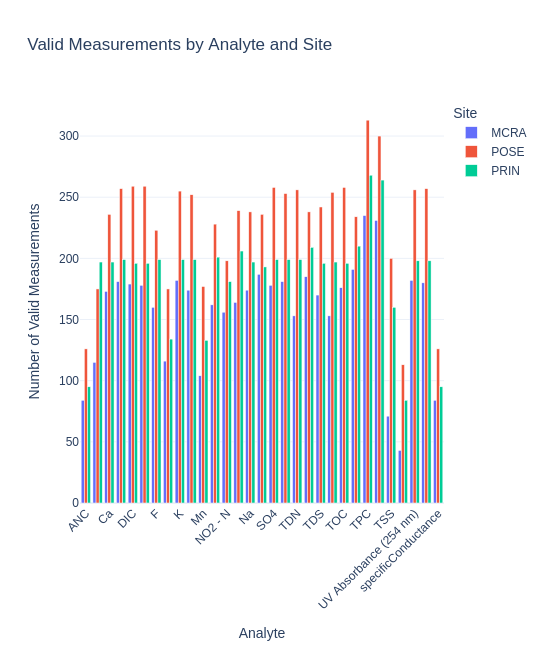

In [21]:
import pandas as pd
import plotly.express as px

coverage_pd = (
    site_quality
    .select("siteID", "analyte", "valid")
    .toPandas()
)

fig = px.bar(
    coverage_pd,
    x="analyte",
    y="valid",
    color="siteID",
    barmode="group",
    title="Valid Measurements by Analyte and Site",
    labels={
        "analyte": "Analyte",
        "valid": "Number of Valid Measurements",
        "siteID": "Site"
    }
)

fig.update_layout(
    xaxis_tickangle=-45,
    height=650,
    template="plotly_white"
)

fig.show()


## 8. Major-ion concentration analysis

 compares these major ions:

`Ca`, `Mg`, `Na`, `K`, `Cl`, `SO4`, `Br`, `F`



In [22]:
major_ions = ["Ca", "Mg", "Na", "K", "Cl", "SO4", "Br", "F"]

major_ion_data = (
    chemistry
    .filter(col("analyte").isin(major_ions))
    .filter(col("concentration_numeric").isNotNull())
    .select(
        "siteID",
        "analyte",
        "analyteUnits",
        col("concentration_numeric").alias("concentration")
    )
)

major_ion_data.show(20, truncate=False)


+------+-------+------------------+-------------+
|siteID|analyte|analyteUnits      |concentration|
+------+-------+------------------+-------------+
|POSE  |K      |milligramsPerLiter|0.727        |
|POSE  |Mg     |milligramsPerLiter|5.9659       |
|POSE  |Br     |milligramsPerLiter|0.0578       |
|POSE  |Cl     |milligramsPerLiter|2.6733       |
|POSE  |SO4    |milligramsPerLiter|1.4483       |
|POSE  |F      |milligramsPerLiter|0.0609       |
|POSE  |Na     |milligramsPerLiter|5.4519       |
|POSE  |Ca     |milligramsPerLiter|18.7825      |
|POSE  |SO4    |milligramsPerLiter|3.6656       |
|POSE  |Na     |milligramsPerLiter|4.7165       |
|POSE  |Cl     |milligramsPerLiter|2.5354       |
|POSE  |Mg     |milligramsPerLiter|4.8354       |
|POSE  |K      |milligramsPerLiter|0.6901       |
|POSE  |F      |milligramsPerLiter|0.0597       |
|POSE  |Ca     |milligramsPerLiter|14.7044      |
|POSE  |Cl     |milligramsPerLiter|0.5414       |
|POSE  |Ca     |milligramsPerLiter|11.2191      |


26/08/31 20:04:50 WARN DAGScheduler: Broadcasting large task binary with size 3.4 MiB
26/08/31 20:04:50 WARN DAGScheduler: Broadcasting large task binary with size 3.4 MiB


In [23]:
# Distribution statistics for each site × major ion.

major_ion_distribution = (
    major_ion_data
    .groupBy("siteID", "analyte", "analyteUnits")
    .agg(
        count("concentration").alias("n"),
        round(avg("concentration"), 4).alias("mean"),
        round(min("concentration"), 4).alias("min"),
        round(max("concentration"), 4).alias("max")
    )
    .orderBy("siteID", "analyte")
)

major_ion_distribution.show(200, truncate=False)


26/08/31 20:04:50 WARN DAGScheduler: Broadcasting large task binary with size 3.4 MiB
[Stage 1180:=============================================>     (243 + 12) / 272]

+------+-------+------------------+---+-------+------+--------+
|siteID|analyte|analyteUnits      |n  |mean   |min   |max     |
+------+-------+------------------+---+-------+------+--------+
|MCRA  |Br     |milligramsPerLiter|115|0.1287 |6.0E-4|13.4805 |
|MCRA  |Ca     |milligramsPerLiter|173|3.7121 |1.328 |89.614  |
|MCRA  |Cl     |milligramsPerLiter|169|1.8051 |0.005 |18.96   |
|MCRA  |Cl     |NULL              |12 |0.6003 |0.1766|1.1137  |
|MCRA  |F      |milligramsPerLiter|153|0.0899 |0.005 |1.4226  |
|MCRA  |F      |NULL              |7  |0.0853 |6.0E-4|0.545   |
|MCRA  |K      |milligramsPerLiter|182|0.4004 |5.0E-4|4.469   |
|MCRA  |Mg     |milligramsPerLiter|174|1.4213 |0.002 |58.95   |
|MCRA  |Na     |milligramsPerLiter|174|1.9574 |5.0E-4|22.82   |
|MCRA  |SO4    |milligramsPerLiter|165|0.6476 |0.005 |13.67   |
|MCRA  |SO4    |NULL              |13 |0.3103 |0.2143|0.449   |
|POSE  |Br     |milligramsPerLiter|166|0.0265 |5.0E-4|0.93    |
|POSE  |Br     |NULL              |9  |0

/home/vishnu/miniconda3/envs/spark/lib/python3.11/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
/home/vishnu/miniconda3/envs/spark/lib/python3.11/site-packages/pyspark/sql/pandas/conversion.py:348: UserWarning: toPandas attempted Arrow optimization because 'spark.sql.execution.arrow.pyspark.enabled' is set to true; however, failed by the reason below:
  [PACKAGE_NOT_INSTALLED] PyArrow >= 18.0.0 must be installed; however, it was not found.
Attempting non-optimization as 'spark.sql.execution.arrow.pyspark.fallback.enabled' is set to true.
  warn(msg)
26/08/31 20:04:53 WARN DAGScheduler: Broadcasting large task binary with size 3.4 MiB
                                                                                

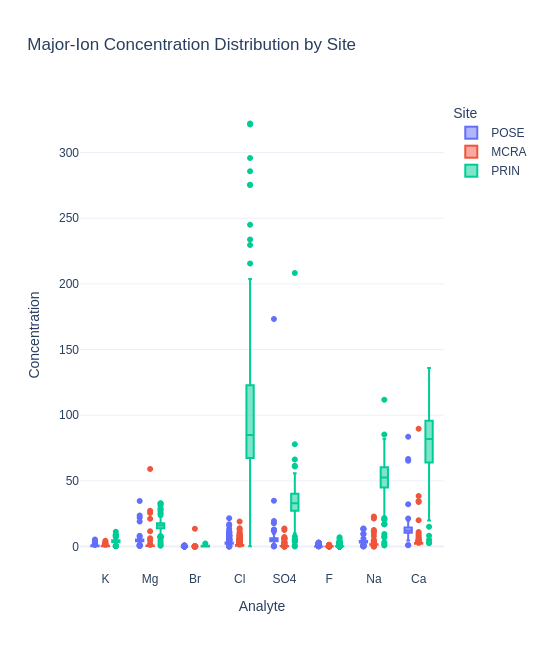

In [24]:
# Box plot — same analysis idea as the reference PDF.

major_ions_pd = major_ion_data.toPandas()

if not major_ions_pd.empty:
    fig = px.box(
        major_ions_pd,
        x="analyte",
        y="concentration",
        color="siteID",
        points="outliers",
        title="Major-Ion Concentration Distribution by Site",
        labels={
            "analyte": "Analyte",
            "concentration": "Concentration",
            "siteID": "Site"
        }
    )

    fig.update_layout(
        height=650,
        template="plotly_white"
    )

    fig.show()


## 9. Average major-ion concentration by site

This corresponds to the average-concentration comparison in the reference.


In [25]:
average_major_ion = (
    major_ion_data
    .groupBy("siteID", "analyte")
    .agg(
        round(avg("concentration"), 4)
        .alias("averageConcentration")
    )
    .orderBy("analyte", "siteID")
)

average_major_ion.show(200, truncate=False)


26/08/31 20:04:57 WARN DAGScheduler: Broadcasting large task binary with size 3.4 MiB
[Stage 1184:===============================================>   (253 + 12) / 272]

+------+-------+--------------------+
|siteID|analyte|averageConcentration|
+------+-------+--------------------+
|MCRA  |Br     |0.1287              |
|POSE  |Br     |0.0323              |
|PRIN  |Br     |0.3731              |
|MCRA  |Ca     |3.7121              |
|POSE  |Ca     |13.1392             |
|PRIN  |Ca     |79.4959             |
|MCRA  |Cl     |1.7252              |
|POSE  |Cl     |3.2255              |
|PRIN  |Cl     |96.2288             |
|MCRA  |F      |0.0897              |
|POSE  |F      |0.2122              |
|PRIN  |F      |0.6562              |
|MCRA  |K      |0.4004              |
|POSE  |K      |0.5836              |
|PRIN  |K      |4.1213              |
|MCRA  |Mg     |1.4213              |
|POSE  |Mg     |4.9107              |
|PRIN  |Mg     |15.829              |
|MCRA  |Na     |1.9574              |
|POSE  |Na     |3.7317              |
|PRIN  |Na     |51.3343             |
|MCRA  |SO4    |0.623               |
|POSE  |SO4    |6.091               |
|PRIN  |SO4 

/home/vishnu/miniconda3/envs/spark/lib/python3.11/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
/home/vishnu/miniconda3/envs/spark/lib/python3.11/site-packages/pyspark/sql/pandas/conversion.py:348: UserWarning: toPandas attempted Arrow optimization because 'spark.sql.execution.arrow.pyspark.enabled' is set to true; however, failed by the reason below:
  [PACKAGE_NOT_INSTALLED] PyArrow >= 18.0.0 must be installed; however, it was not found.
Attempting non-optimization as 'spark.sql.execution.arrow.pyspark.fallback.enabled' is set to true.
  warn(msg)
26/08/31 20:05:00 WARN DAGScheduler: Broadcasting large task binary with size 3.4 MiB
                                                                                

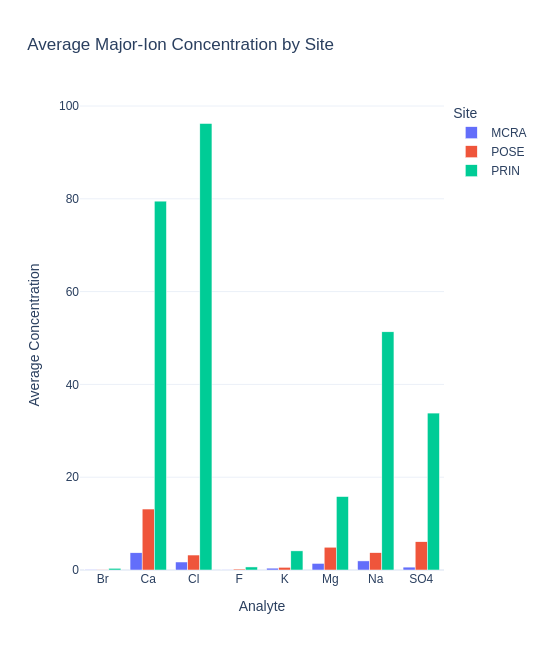

In [26]:
average_pd = average_major_ion.toPandas()

if not average_pd.empty:
    fig = px.bar(
        average_pd,
        x="analyte",
        y="averageConcentration",
        color="siteID",
        barmode="group",
        title="Average Major-Ion Concentration by Site",
        labels={
            "analyte": "Analyte",
            "averageConcentration": "Average Concentration",
            "siteID": "Site"
        }
    )

    fig.update_layout(
        height=650,
        template="plotly_white"
    )

    fig.show()


## 10. Total major-ion concentration by site

 calculates the total concentration of the selected major ions for each site.


In [27]:
total_major_ion = (
    major_ion_data
    .groupBy("siteID")
    .agg(
        round(sum("concentration"), 4)
        .alias("totalConcentration")
    )
    .orderBy(desc("totalConcentration"))
)

total_major_ion.show(100, truncate=False)


26/08/31 20:05:04 WARN DAGScheduler: Broadcasting large task binary with size 3.4 MiB
[Stage 1195:==================================================> (264 + 8) / 272]

+------+------------------+
|siteID|totalConcentration|
+------+------------------+
|PRIN  |55827.5041        |
|POSE  |7828.695          |
|MCRA  |1755.2612         |
+------+------------------+



/home/vishnu/miniconda3/envs/spark/lib/python3.11/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
/home/vishnu/miniconda3/envs/spark/lib/python3.11/site-packages/pyspark/sql/pandas/conversion.py:348: UserWarning: toPandas attempted Arrow optimization because 'spark.sql.execution.arrow.pyspark.enabled' is set to true; however, failed by the reason below:
  [PACKAGE_NOT_INSTALLED] PyArrow >= 18.0.0 must be installed; however, it was not found.
Attempting non-optimization as 'spark.sql.execution.arrow.pyspark.fallback.enabled' is set to true.
  warn(msg)
26/08/31 20:05:07 WARN DAGScheduler: Broadcasting large task binary with size 3.4 MiB
                                                                                

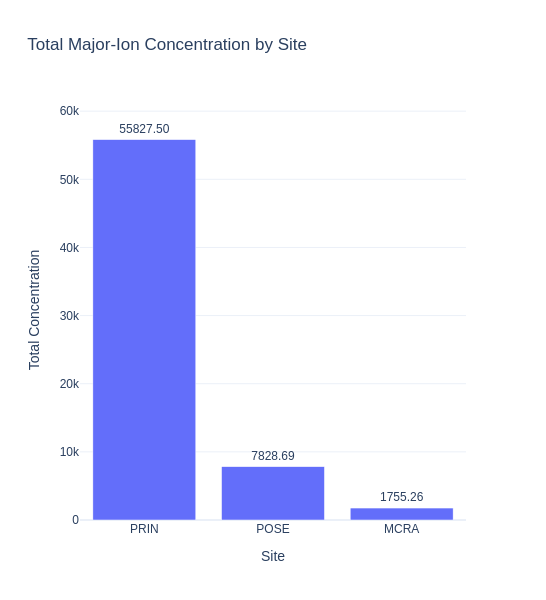

In [28]:
total_pd = total_major_ion.toPandas()

if not total_pd.empty:
    fig = px.bar(
        total_pd,
        x="siteID",
        y="totalConcentration",
        text="totalConcentration",
        title="Total Major-Ion Concentration by Site",
        labels={
            "siteID": "Site",
            "totalConcentration": "Total Concentration"
        }
    )

    fig.update_traces(texttemplate="%{text:.2f}", textposition="outside")

    fig.update_layout(
        height=600,
        template="plotly_white"
    )

    fig.show()


## 11. Correlation matrices
 creates a separate Pearson correlation heatmap for each site. It groups repeated observations by sample identifier and analyte, pivots analytes into columns, and calculates correlations.

The code below automatically selects `sampleID`, `sampleCode`, or `uid`, whichever is available.


In [29]:
sample_id_candidates = ["sampleID", "sampleCode", "uid"]

sample_id_column = next(
    (c for c in sample_id_candidates if c in chemistry.columns),
    None
)

if sample_id_column is None:
    raise ValueError(
        "No sample identifier found. Available columns: "
        + ", ".join(chemistry.columns)
    )

print("Using sample identifier:", sample_id_column)


Using sample identifier: sampleID


In [30]:
# Build one concentration value per sample × site × analyte.

corr_input = (
    chemistry
    .filter(col("analyte").isin(major_ions))
    .filter(col("concentration_numeric").isNotNull())
    .filter(col("siteID").isNotNull())
    .filter(col(sample_id_column).isNotNull())
    .groupBy("siteID", sample_id_column, "analyte")
    .agg(
        avg("concentration_numeric").alias("concentration")
    )
)

sites = [
    row["siteID"]
    for row in corr_input
    .select("siteID")
    .distinct()
    .orderBy("siteID")
    .collect()
]

print("Sites included in correlation analysis:", sites)


26/08/31 20:05:10 WARN DAGScheduler: Broadcasting large task binary with size 3.4 MiB
[Stage 1206:===================================================>(268 + 4) / 272]

Sites included in correlation analysis: ['MCRA', 'POSE', 'PRIN']


/home/vishnu/miniconda3/envs/spark/lib/python3.11/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
/home/vishnu/miniconda3/envs/spark/lib/python3.11/site-packages/pyspark/sql/pandas/conversion.py:348: UserWarning: toPandas attempted Arrow optimization because 'spark.sql.execution.arrow.pyspark.enabled' is set to true; however, failed by the reason below:
  [PACKAGE_NOT_INSTALLED] PyArrow >= 18.0.0 must be installed; however, it was not found.
Attempting non-optimization as 'spark.sql.execution.arrow.pyspark.fallback.enabled' is set to true.
  warn(msg)
26/08/31 20:05:14 WARN DAGScheduler: Broadcasting large task binary with size 3.4 MiB
                                                                                

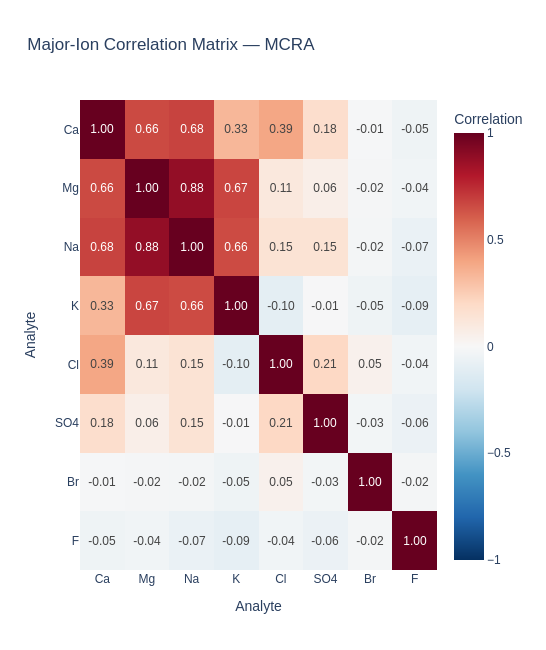

/home/vishnu/miniconda3/envs/spark/lib/python3.11/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
/home/vishnu/miniconda3/envs/spark/lib/python3.11/site-packages/pyspark/sql/pandas/conversion.py:348: UserWarning: toPandas attempted Arrow optimization because 'spark.sql.execution.arrow.pyspark.enabled' is set to true; however, failed by the reason below:
  [PACKAGE_NOT_INSTALLED] PyArrow >= 18.0.0 must be installed; however, it was not found.
Attempting non-optimization as 'spark.sql.execution.arrow.pyspark.fallback.enabled' is set to true.
  warn(msg)
26/08/31 20:05:17 WARN DAGScheduler: Broadcasting large task binary with size 3.4 MiB
                                                                                

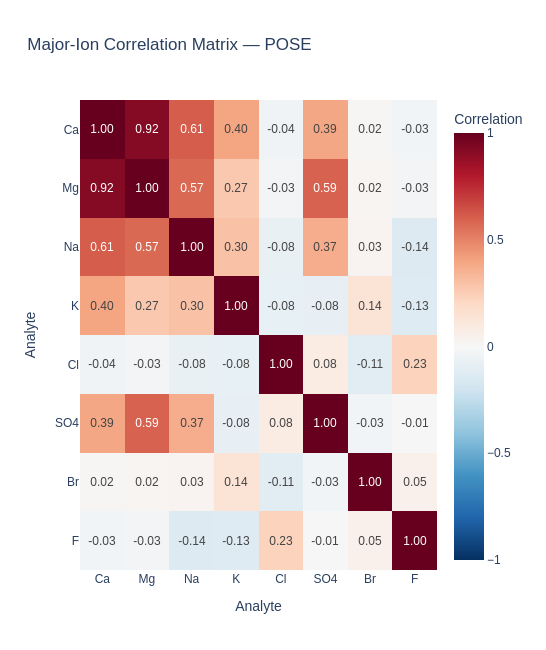

/home/vishnu/miniconda3/envs/spark/lib/python3.11/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
/home/vishnu/miniconda3/envs/spark/lib/python3.11/site-packages/pyspark/sql/pandas/conversion.py:348: UserWarning: toPandas attempted Arrow optimization because 'spark.sql.execution.arrow.pyspark.enabled' is set to true; however, failed by the reason below:
  [PACKAGE_NOT_INSTALLED] PyArrow >= 18.0.0 must be installed; however, it was not found.
Attempting non-optimization as 'spark.sql.execution.arrow.pyspark.fallback.enabled' is set to true.
  warn(msg)
26/08/31 20:05:20 WARN DAGScheduler: Broadcasting large task binary with size 3.4 MiB
                                                                                

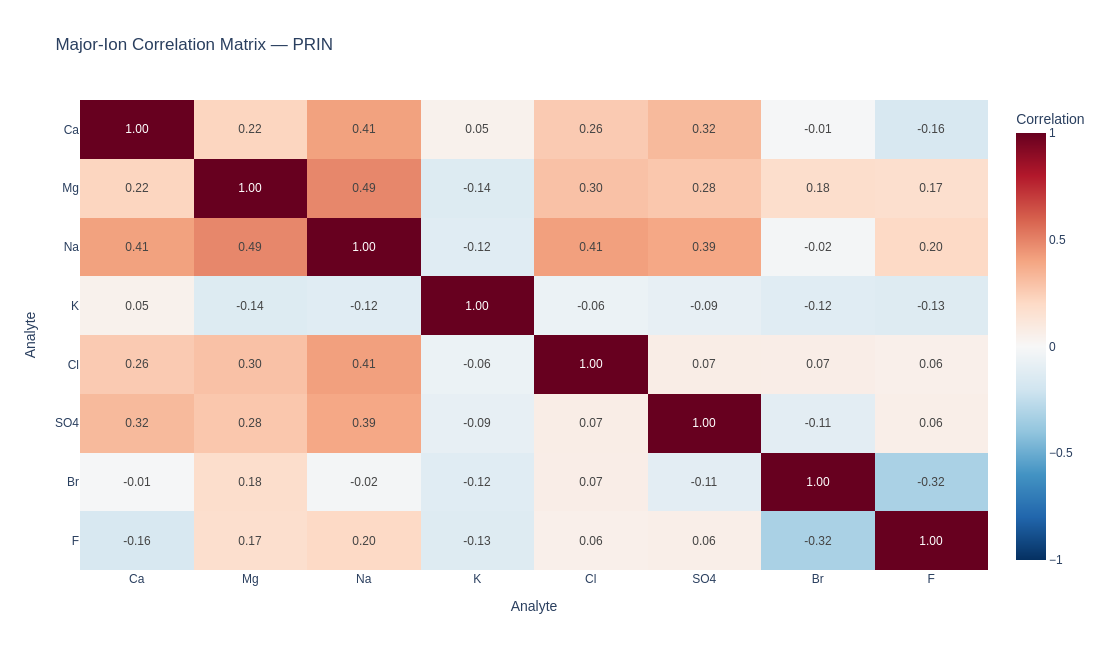

In [31]:
# Correlation heatmap for every remaining site.

for site in sites:
    site_df = (
        corr_input
        .filter(col("siteID") == site)
        .groupBy(sample_id_column)
        .pivot("analyte", major_ions)
        .agg(avg("concentration"))
    )

    available_ions = [
        ion for ion in major_ions
        if ion in site_df.columns
    ]

    if len(available_ions) < 2:
        print(f"Skipping {site}: fewer than two major ions available.")
        continue

    corr_pd = site_df.select(available_ions).toPandas()

    if corr_pd.empty:
        print(f"Skipping {site}: no usable observations.")
        continue

    corr_matrix = corr_pd.corr(method="pearson")

    fig = px.imshow(
        corr_matrix,
        text_auto=".2f",
        aspect="auto",
        zmin=-1,
        zmax=1,
        color_continuous_scale="RdBu_r",
        title=f"Major-Ion Correlation Matrix — {site}",
        labels={
            "x": "Analyte",
            "y": "Analyte",
            "color": "Correlation"
        }
    )

    fig.update_layout(
        height=650,
        width=750,
        template="plotly_white"
    )

    fig.show()


## 12. Strongest major-ion relationships

This is an additional compact view of the correlation output, useful when the heatmaps are difficult to read.


In [ ]:
for site in sites:
    site_df = (
        corr_input
        .filter(col("siteID") == site)
        .groupBy(sample_id_column)
        .pivot("analyte", major_ions)
        .agg(avg("concentration"))
    )

    available_ions = [ion for ion in major_ions if ion in site_df.columns]

    if len(available_ions) < 2:
        continue

    corr_pd = site_df.select(available_ions).toPandas()

    if corr_pd.empty:
        continue

    corr = corr_pd.corr(method="pearson")

    pairs = []
    for i, a in enumerate(available_ions):
        for b in available_ions[i + 1:]:
            value = corr.loc[a, b]
            if pd.notna(value):
                pairs.append((a, b, float(value), abs(float(value))))

    pairs.sort(key=lambda x: x[3], reverse=True)

    print(f"\nTop Pearson correlations for {site}")
    print("-" * 55)

    for a, b, r, absolute_r in pairs[:10]:
        print(f"{a:>6} vs {b:<6}  r = {r: .3f}")


/home/vishnu/miniconda3/envs/spark/lib/python3.11/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
/home/vishnu/miniconda3/envs/spark/lib/python3.11/site-packages/pyspark/sql/pandas/conversion.py:348: UserWarning: toPandas attempted Arrow optimization because 'spark.sql.execution.arrow.pyspark.enabled' is set to true; however, failed by the reason below:
  [PACKAGE_NOT_INSTALLED] PyArrow >= 18.0.0 must be installed; however, it was not found.
Attempting non-optimization as 'spark.sql.execution.arrow.pyspark.fallback.enabled' is set to true.
  warn(msg)
26/08/31 20:05:24 WARN DAGScheduler: Broadcasting large task binary with size 3.4 MiB
/home/vishnu/miniconda3/envs/spark/lib/python3.11/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3


Top Pearson correlations for MCRA
-------------------------------------------------------
    Mg vs Na      r =  0.882
    Ca vs Na      r =  0.681
    Mg vs K       r =  0.675
    Ca vs Mg      r =  0.662
    Na vs K       r =  0.657
    Ca vs Cl      r =  0.393
    Ca vs K       r =  0.332
    Cl vs SO4     r =  0.207
    Ca vs SO4     r =  0.176
    Na vs Cl      r =  0.146


/home/vishnu/miniconda3/envs/spark/lib/python3.11/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
/home/vishnu/miniconda3/envs/spark/lib/python3.11/site-packages/pyspark/sql/pandas/conversion.py:348: UserWarning: toPandas attempted Arrow optimization because 'spark.sql.execution.arrow.pyspark.enabled' is set to true; however, failed by the reason below:
  [PACKAGE_NOT_INSTALLED] PyArrow >= 18.0.0 must be installed; however, it was not found.
Attempting non-optimization as 'spark.sql.execution.arrow.pyspark.fallback.enabled' is set to true.
  warn(msg)
26/08/31 20:05:30 WARN DAGScheduler: Broadcasting large task binary with size 3.4 MiB



Top Pearson correlations for POSE
-------------------------------------------------------
    Ca vs Mg      r =  0.919
    Ca vs Na      r =  0.608
    Mg vs SO4     r =  0.594
    Mg vs Na      r =  0.573
    Ca vs K       r =  0.400
    Ca vs SO4     r =  0.394
    Na vs SO4     r =  0.369
    Na vs K       r =  0.296
    Mg vs K       r =  0.271
    Cl vs F       r =  0.230


[Stage 1264:=============>                                      (70 + 12) / 272]